In [1]:
import itertools
import math
import cmath
import time
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
import ffsim
import pyscf
from pyscf import gto, scf, cc
from ffsim.linalg import givens_decomposition
from qiskit.circuit.library import XXPlusYYGate

from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap

import cirq
import quimb as qu
import quimb.tensor as qtn

from cirq.contrib.qasm_import import circuit_from_qasm

import matplotlib.pyplot as plt

## Molecule definition

In [2]:
def generate_hchain_geometry(natoms: int, atomic_distance: float = 0.7) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.
    
    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"H 0 0 {i * atomic_distance}" for i in range(natoms)])

In [3]:
def orbital_rotation(qc_lucj, orbital_rotation, N): # N/2 = mol.nao_nr()
    nao_nr = N//2

    givens_rotations, phase_shifts = givens_decomposition(orbital_rotation)
    for c, s, i, j in givens_rotations:
        # print(i, j)
        qc_lucj.append(XXPlusYYGate(theta = 2 * math.acos(c), beta = cmath.phase(s) - 0.5 * math.pi), [i, j])
        qc_lucj.append(XXPlusYYGate(theta = 2 * math.acos(c), beta = cmath.phase(s) - 0.5 * math.pi), [i + nao_nr, j + nao_nr])

    for i, phase_shift in enumerate(phase_shifts):
        qc_lucj.p(cmath.phase(phase_shift), i)
        qc_lucj.p(cmath.phase(phase_shift), i + nao_nr)

    qc_lucj.barrier()

In [4]:
def J_op(qc_lucj, diag_mat_aa, diag_mat_ab, diag_mat_bb, time, norb):
    for sigma, this_mat in enumerate([diag_mat_aa, diag_mat_bb]):
        if this_mat is None:
            print('______________________')
            print('_________NONE_________')
            print('______________________')
        if this_mat is not None:
            for i in range(norb):
                if this_mat[i, i]:
                    # print(i + sigma * norb)
                    qc_lucj.p(-0.5 * this_mat[i, i] * time, i + sigma * norb)
            for i, j in itertools.combinations(range(norb), 2):
                if this_mat[i, j]:
                    # print(i + sigma * norb, j + sigma * norb)
                    qc_lucj.cp(-this_mat[i, j] * time, i + sigma * norb, j + sigma * norb)
    # qc_lucj.barrier()
    if diag_mat_ab is not None:
        for i in range(norb):
            if diag_mat_ab[i, i]:
                qc_lucj.cp(-diag_mat_ab[i, i] * time, i, i + norb)
                
        for i, j in itertools.combinations(range(norb), 2):
            
            if diag_mat_ab[i, j]:
                qc_lucj.cp(-diag_mat_ab[i, j] * time, i, j + norb)
                
            if diag_mat_ab[j, i]:
                qc_lucj.cp(-diag_mat_ab[j, i] * time, j, i + norb)
                

    qc_lucj.barrier()

In [5]:
def generate_circuit(num_atoms):
    geom = generate_hchain_geometry(natoms=num_atoms)

    mol = gto.Mole(atom = geom, charge = 0, basis = 'sto3g')
    mol.build()
    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.kernel()
    cc_ = cc.CCSD(mf).run()
    N = mol.nao_nr() * 2

    # Define active space
    n_frozen = 0
    active_space = range(n_frozen, mol.nao_nr())

    # Get molecular integrals
    scf_ = pyscf.scf.RHF(mol).run()
    norb = len(active_space)
    n_electrons = int(sum(scf_.mo_occ[active_space]))
    n_alpha = (n_electrons + mol.spin) // 2
    n_beta = (n_electrons - mol.spin) // 2
    nelec = (n_alpha, n_beta)
    #cas = pyscf.mcscf.CASCI(scf_, norb, nelec)
    #mo = cas.sort_mo(active_space, base=0)
    #hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
    #eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

    # Compute exact energy using FCI
    #reference_energy = cas.run().e_tot

    # Get CCSD t2 amplitudes for initializing the ansatz
    ccsd = pyscf.cc.CCSD(
        scf_, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
    ).run()
    t1 = ccsd.t1
    t2 = ccsd.t2

    # Set ansatz properties
    n_reps = 1
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]
    pairs_ab = [(p, p) for p in range(norb)]  # None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

    # Initialize backend
    coupling_map = CouplingMap.from_heavy_hex(3)
    backend = GenericBackendV2(
        coupling_map.size(),
        coupling_map=coupling_map,
        basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
    )

    # Create pass manager
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="heavy-hex",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )

    # Create the LUCJ ansatz operator
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(pairs_aa, pairs_ab),
        # Setting optimize=True enables the "compressed" factorization
        optimize=True,
        # Limit the number of optimization iterations to prevent the code cell from running
        # too long. Removing this line may improve results.
        options=dict(maxiter=1000),
    )

    # create an empty quantum circuit
    qubits = QuantumRegister(2 * norb, name="q")
    circuit = QuantumCircuit(qubits)

    # prepare Hartree-Fock state as the reference state and append it to the quantum circuit
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

    # apply the UCJ operator to the reference state
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    circuit.measure_all()

    qc_lucj = QuantumCircuit(N)
    t1, t2 = cc_.t1, cc_.t2

    norb = mol.nao_nr()
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]   # same-spin line
    pairs_ab = [(p, p) for p in range(norb)]           # opposite-spin on-site
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=cc_.t2, t1=cc_.t1,
        n_reps=2,
        interaction_pairs=(pairs_aa, pairs_ab),
    )

    orbital_rotations = ucj_op.orbital_rotations
    diag_mats = ucj_op.diag_coulomb_mats
    final_orbital_rotation = ucj_op.final_orbital_rotation
    for i in range(mol.nelectron // 2):
        qc_lucj.x(i)
        qc_lucj.x(i + mol.nao_nr())
    for orb_rot, (diag_mat_aa, diag_mat_ab) in zip(orbital_rotations, diag_mats):
        orbital_rotation(qc_lucj, orb_rot.T.conj(), N)
        J_op(qc_lucj, diag_mat_aa, diag_mat_ab, diag_mat_aa, time=-1, norb=mol.nao_nr())
        orbital_rotation(qc_lucj, orb_rot, N)
    if ucj_op.final_orbital_rotation is not None:
        orbital_rotation(qc_lucj, ucj_op.final_orbital_rotation, N)

    from qiskit import qasm2
    qasm_str = qasm2.dumps(qc_lucj)

    clean_qs = ""
    for s in qasm_str.splitlines():
        if not s.startswith("barrier"):
            clean_qs += s + "\n"

    cirq_circuit = circuit_from_qasm(clean_qs)
    return cirq_circuit

In [6]:
def gen_circ(natoms):
    # Specify molecule properties
    spin_sq = 0

    # Build N2 molecule
    mol = pyscf.gto.Mole()
    mol.build(
        atom=generate_hchain_geometry(natoms),
        basis="sto-6g",
    )

    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.kernel()
    cc_ = cc.CCSD(mf).run()
    N = mol.nao_nr() * 2

    # Define active space
    n_frozen = 0
    active_space = range(n_frozen, mol.nao_nr())

    # Get molecular integrals
    scf_ = pyscf.scf.RHF(mol).run()
    norb = len(active_space)
    n_electrons = int(sum(scf_.mo_occ[active_space]))
    n_alpha = (n_electrons + mol.spin) // 2
    n_beta = (n_electrons - mol.spin) // 2
    nelec = (n_alpha, n_beta)
    #cas = pyscf.mcscf.CASCI(scf, norb, nelec)
    #mo = cas.sort_mo(active_space, base=0)
    #hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
    #eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

    # Compute exact energy using FCI
    # reference_energy = cas.run().e_tot

    # Get CCSD t2 amplitudes for initializing the ansatz
    ccsd = pyscf.cc.CCSD(
        scf_, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
    ).run()
    t1 = ccsd.t1
    t2 = ccsd.t2

    import warnings

    from qiskit.transpiler import CouplingMap

    warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

    # Set ansatz properties
    n_reps = 1
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]
    pairs_ab = None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

    # Initialize backend
    coupling_map = CouplingMap.from_grid(
        num_rows=int(np.ceil(np.sqrt(2 * norb))),
        num_columns=int(np.ceil(np.sqrt(2 * norb)))
    )
    backend = GenericBackendV2(
        coupling_map.size(),
        coupling_map=coupling_map,
        basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
    )

    # Create pass manager
    try:
        pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
            backend=backend,
            norb=norb,
            connectivity="heavy-hex",
            interaction_pairs=(pairs_aa, pairs_ab),
            optimization_level=3,
        )
        print("Unable to generate ffsim pass manager")
    except RuntimeError:
        pass_manager = None

    # Create the LUCJ ansatz operator
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(pairs_aa, pairs_ab),
        # Setting optimize=True enables the "compressed" factorization
        optimize=True,
        # Limit the number of optimization iterations to prevent the code cell from running
        # too long. Removing this line may improve results.
        options=dict(maxiter=1000),
    )

    # create an empty quantum circuit
    qubits = QuantumRegister(2 * norb, name="q")
    circuit = QuantumCircuit(qubits)

    # prepare Hartree-Fock state as the reference state and append it to the quantum circuit
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

    # apply the UCJ operator to the reference state
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    # circuit.measure_all()

    qc_lucj = QuantumCircuit(mol.nao_nr() * 2)
    t1, t2 = cc_.t1, cc_.t2

    norb = mol.nao_nr()
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]   # same-spin line
    pairs_ab = [(p, p) for p in range(norb)]           # opposite-spin on-site
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=cc_.t2, t1=cc_.t1,
        n_reps=2,
        interaction_pairs=(pairs_aa, pairs_ab),
    )

    orbital_rotations = ucj_op.orbital_rotations
    diag_mats = ucj_op.diag_coulomb_mats
    final_orbital_rotation = ucj_op.final_orbital_rotation
    for i in range(mol.nelectron // 2):
        qc_lucj.x(i)
        qc_lucj.x(i + mol.nao_nr())
    for orb_rot, (diag_mat_aa, diag_mat_ab) in zip(orbital_rotations, diag_mats):
        orbital_rotation(qc_lucj, orb_rot.T.conj(), N)
        J_op(qc_lucj, diag_mat_aa, diag_mat_ab, diag_mat_aa, time=-1, norb=mol.nao_nr())
        orbital_rotation(qc_lucj, orb_rot, N)
    if ucj_op.final_orbital_rotation is not None:
        orbital_rotation(qc_lucj, ucj_op.final_orbital_rotation, N)

    from qiskit import qasm2
    qasm_str = qasm2.dumps(qc_lucj)

    clean_qs = ""
    for s in qasm_str.splitlines():
        if not s.startswith("barrier"):
            clean_qs += s + "\n"

    cirq_circuit = circuit_from_qasm(clean_qs)
    return cirq_circuit

In [7]:
def simulate_cpu(circuit: cirq.Circuit, dtype: str = "float64", verbose: bool = False) -> qtn.MatrixProductState:
    qubits_to_indices = {q: i for i, q in enumerate(sorted(circuit.all_qubits()))}
    nqubits = len(qubits_to_indices)

    mps = qtn.MPS_computational_state("0" * nqubits, dtype=dtype, cyclic=False)
    num_ops = len(list(circuit.all_operations()))
    for i, op in enumerate(circuit.all_operations()):
        mps.gate_(
            qu.qarray(cirq.unitary(op)),
            [qubits_to_indices[q] for q in op.qubits],
            contract="swap+split",
        )
        if verbose:
            print(f"\rOp {i + 1} / {num_ops}", end=" ")
            if i % 50 == 0:
                print(mps.bond_sizes())

    return mps

In [8]:
def benchmark_creation(num_atoms):
    c_start = time.perf_counter()
    circuit = gen_circ(num_atoms)
    c_end = time.perf_counter()

    s_start = time.perf_counter()
    mps = simulate_cpu(circuit)
    s_end = time.perf_counter()

    create_time = c_end - c_start
    simulate_time = s_end - s_start

    return create_time, simulate_time

E(CCSD) = -1.144979198010311  E_corr = -0.01887889514455725
converged SCF energy = -1.12610030286575
E(CCSD) = -1.144979198010311  E_corr = -0.01887889514455725


Removing interaction (0, 0) from the end.



# Atoms: 2		Create Time: 2.311110		Simulate Time: 0.029868

E(CCSD) = -2.125732168713052  E_corr = -0.03781800394554854
converged SCF energy = -2.0879141647675
E(CCSD) = -2.125732168713052  E_corr = -0.03781800394554854
Unable to generate ffsim pass manager

# Atoms: 4		Create Time: 2.708760		Simulate Time: 0.050128

E(CCSD) = -3.107605090199753  E_corr = -0.05763608007517145
converged SCF energy = -3.04996901012458
E(CCSD) = -3.107605090199753  E_corr = -0.05763608007517145
Unable to generate ffsim pass manager

# Atoms: 6		Create Time: 10.572536		Simulate Time: 0.198038

E(CCSD) = -4.090881798948535  E_corr = -0.07780482820409274
converged SCF energy = -4.01307697074444
E(CCSD) = -4.090881798948535  E_corr = -0.07780482820409274


Removing interaction (4, 4) from the end.
Removing interaction (0, 0) from the end.



# Atoms: 8		Create Time: 28.606918		Simulate Time: 0.420964

E(CCSD) = -5.075058185149681  E_corr = -0.09816608756830893
converged SCF energy = -4.97689209758137
E(CCSD) = -5.075058185149681  E_corr = -0.09816608756830893
Unable to generate ffsim pass manager

# Atoms: 10		Create Time: 29.475353		Simulate Time: 0.937706

E(CCSD) = -6.059800548195338  E_corr = -0.1186467537151166
converged SCF energy = -5.94115379448022
E(CCSD) = -6.059800548195338  E_corr = -0.1186467537151166
Unable to generate ffsim pass manager


...


# Atoms: 12		Create Time: 29.244660		Simulate Time: 2.081828

E(CCSD) = -7.044909749575346  E_corr = -0.1392078972004071
converged SCF energy = -6.90570185237494
E(CCSD) = -7.044909749575346  E_corr = -0.1392078972004071
Unable to generate ffsim pass manager

# Atoms: 14		Create Time: 29.629180		Simulate Time: 7.891384

E(CCSD) = -8.030265286248955  E_corr = -0.1598266796838524
converged SCF energy = -7.8704386065651
E(CCSD) = -8.030265286248955  E_corr = -0.1598266796838524
Unable to generate ffsim pass manager


Removing interaction (12, 12) from the end.
Removing interaction (8, 8) from the end.



# Atoms: 16		Create Time: 39.727021		Simulate Time: 30.006530

E(CCSD) = -9.015791752863304  E_corr = -0.1804887990009653
converged SCF energy = -8.83530295386234
E(CCSD) = -9.015791752863304  E_corr = -0.1804887990009653


Removing interaction (16, 16) from the end.
Removing interaction (12, 12) from the end.
Removing interaction (8, 8) from the end.
Removing interaction (4, 4) from the end.
Removing interaction (0, 0) from the end.



# Atoms: 18		Create Time: 31.970632		Simulate Time: 120.444395



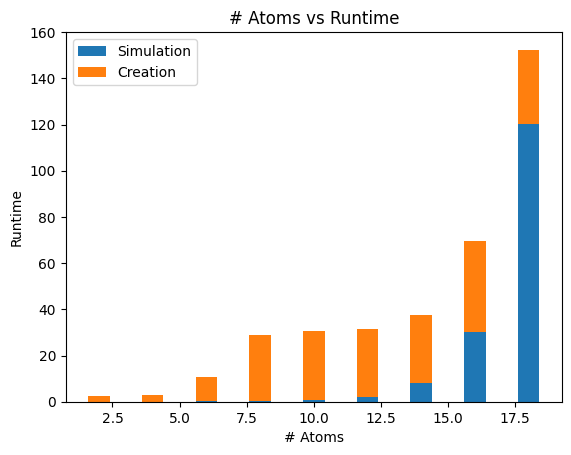

In [9]:
create_times = []
simulate_times = []

nums = range(2,20,2)

'''
import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()
benchmark_creation(6)
profiler.disable()

stats = pstats.Stats(profiler)
stats.sort_stats('cumulative')
stats.print_stats(100)
'''

with open("bench.txt", "w") as file:
    for n in nums:
        crt, sit = benchmark_creation(n)
        create_times.append(crt)
        simulate_times.append(sit)
        file.write(f"# Atoms: {n}\t\tCreate Time: {crt:.6f}\t\tSimulate Time: {sit:.6f}\n")
        print(f"\n# Atoms: {n}\t\tCreate Time: {crt:.6f}\t\tSimulate Time: {sit:.6f}\n")

# also plot depth vs runtime (fixed at ~30 atoms)

plt.bar(nums, simulate_times, label="Simulation")
plt.bar(nums, create_times, bottom=simulate_times, label="Creation")

plt.xlabel("# Atoms")
plt.ylabel("Runtime")
plt.title("# Atoms vs Runtime")
plt.legend()

plt.show()